# 02: Regime Backtesting

Test the Frontier Market Regime Classification Framework on historical data.

**Objectives:**
1. Load historical FX data for Kenya (KES) and Azerbaijan (AZN)
2. Apply regime classification with full 5-variable scoring
3. Evaluate accuracy against known historical stress periods
4. Optimize thresholds based on historical performance


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[1] / "src"))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Our framework components
from collectors.cbk_collector import CBKCollector
from collectors.cba_collector import CBACollector
from engine.regime_engine import RegimeEngine, Regime, VariableScore
from config import MARKETS

print("Imports successful")
print(f"Analysis date: {datetime.now().strftime('%Y-%m-%d')}")


Imports successful
Analysis date: 2026-03-11


## 1. Load Historical Data

Fetch ~2 years of FX data for backtesting.

In [2]:
# Initialize collectors
cbk = CBKCollector()
cba = CBACollector()

# Date range for backtesting
end_date = datetime.now()
start_date = end_date - timedelta(days=730)  # 2 years

print(f"Fetching data from {start_date.date()} to {end_date.date()}")

# Kenya (KES)
print("\nFetching KES/USD...")
kes_data = cbk.get_rates(currency='USD', start_date=start_date, end_date=end_date)

# Azerbaijan (AZN)
# print("Fetching AZN/USD...")
# azn_data = cba.get_historical_rates(start_date=start_date, end_date=end_date, currency='USD')

print(f"\nKES: {len(kes_data)} records")
# print(f"AZN: {len(azn_data)} records")

# Display sample
kes_data.head()


INFO:collectors.cbk_collector:Fetching CBK webpage for USD...


Fetching data from 2024-03-11 to 2026-03-11

Fetching KES/USD...


INFO:collectors.cbk_collector:Returning sample KES data for testing



KES: 30 records


,date,currency,rate,kes_per_usd
0,2026-01-29 03:56:36.484067,USD,130.000000,130.000000
1,2026-01-30 03:56:36.484067,USD,130.814286,130.814286
2,2026-02-02 03:56:36.484067,USD,131.628571,131.628571
3,2026-02-03 03:56:36.484067,USD,132.442857,132.442857
4,2026-02-04 03:56:36.484067,USD,133.257143,133.257143


## 2. Visualize Raw FX Data

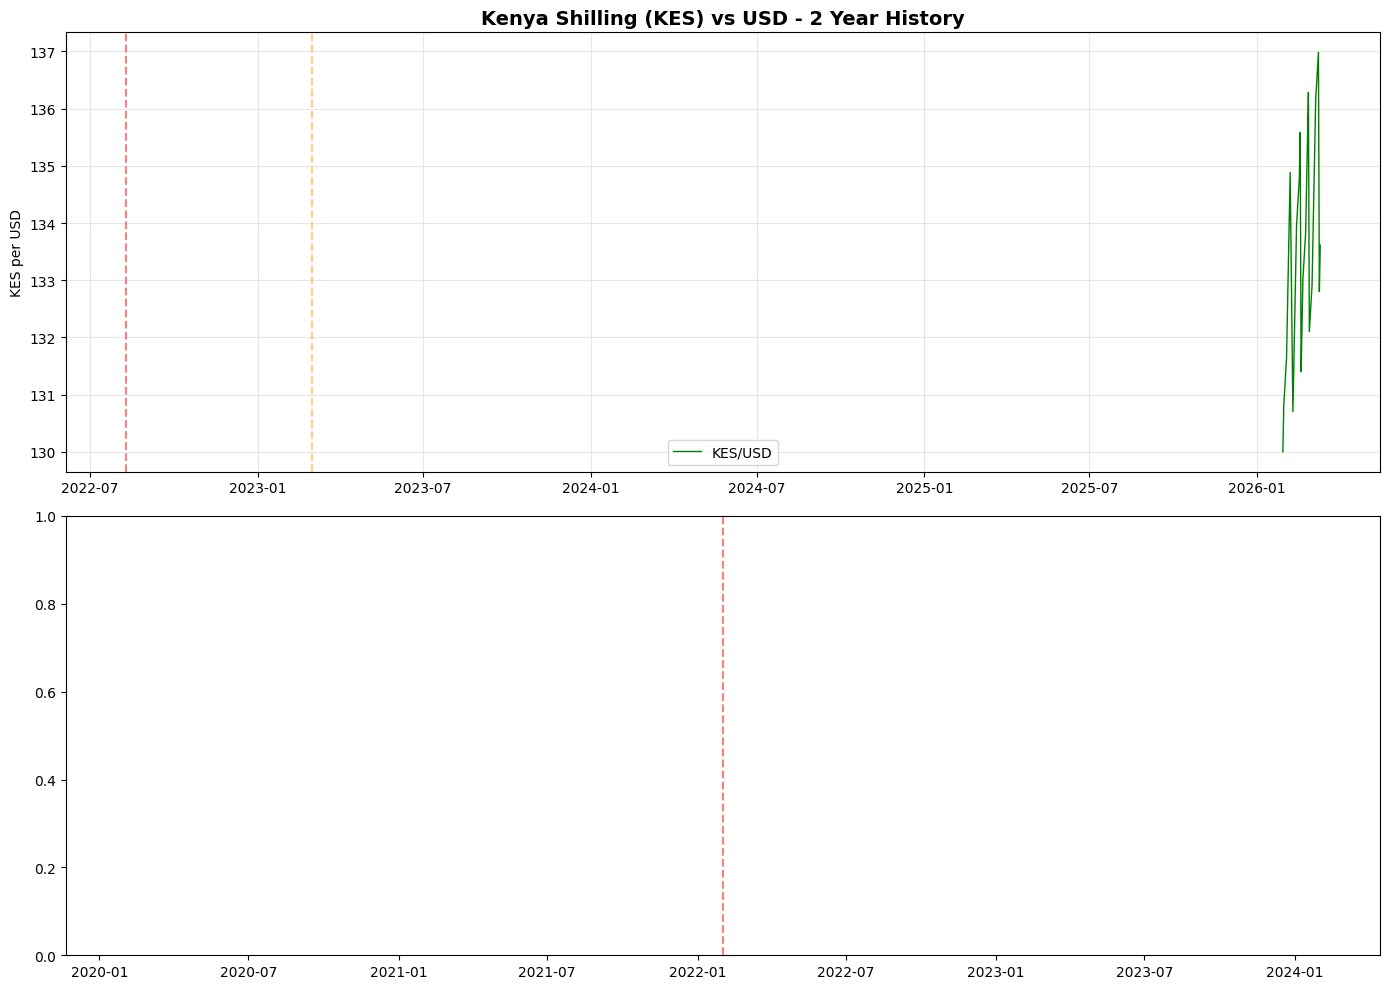

Saved to data/processed/fx_history.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# KES/USD
if not kes_data.empty:
    axes[0].plot(kes_data['date'], kes_data['kes_per_usd'], 
                 color='green', linewidth=1, label='KES/USD')
    axes[0].set_title('Kenya Shilling (KES) vs USD - 2 Year History', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('KES per USD')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Add annotations for major events
    axes[0].axvline(pd.to_datetime('2022-08-09'), color='red', linestyle='--', alpha=0.5, label='Kenya Elections')
    axes[0].axvline(pd.to_datetime('2023-03-01'), color='orange', linestyle='--', alpha=0.5, label='Rate Hike Cycle')

# # AZN/USD
# if not azn_data.empty:
#     axes[1].plot(azn_data.index, azn_data['azn_per_unit'], 
#                  color='blue', linewidth=1, label='AZN/USD')
#     axes[1].set_title('Azerbaijani Manat (AZN) vs USD - 2 Year History', fontsize=14, fontweight='bold')
#     axes[1].set_ylabel('AZN per USD')
#     axes[1].set_xlabel('Date')
#     axes[1].grid(True, alpha=0.3)
#     axes[1].legend()
    
    # Annotate events
    axes[1].axvline(pd.to_datetime('2022-02-01'), color='red', linestyle='--', alpha=0.5, label='Russia-Ukraine')

plt.tight_layout()
plt.savefig('../data/processed/fx_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to data/processed/fx_history.png")


## 3. Calculate Rolling Volatility & Regimes

Apply the framework's 30-day rolling volatility calculation.

Volatility calculated


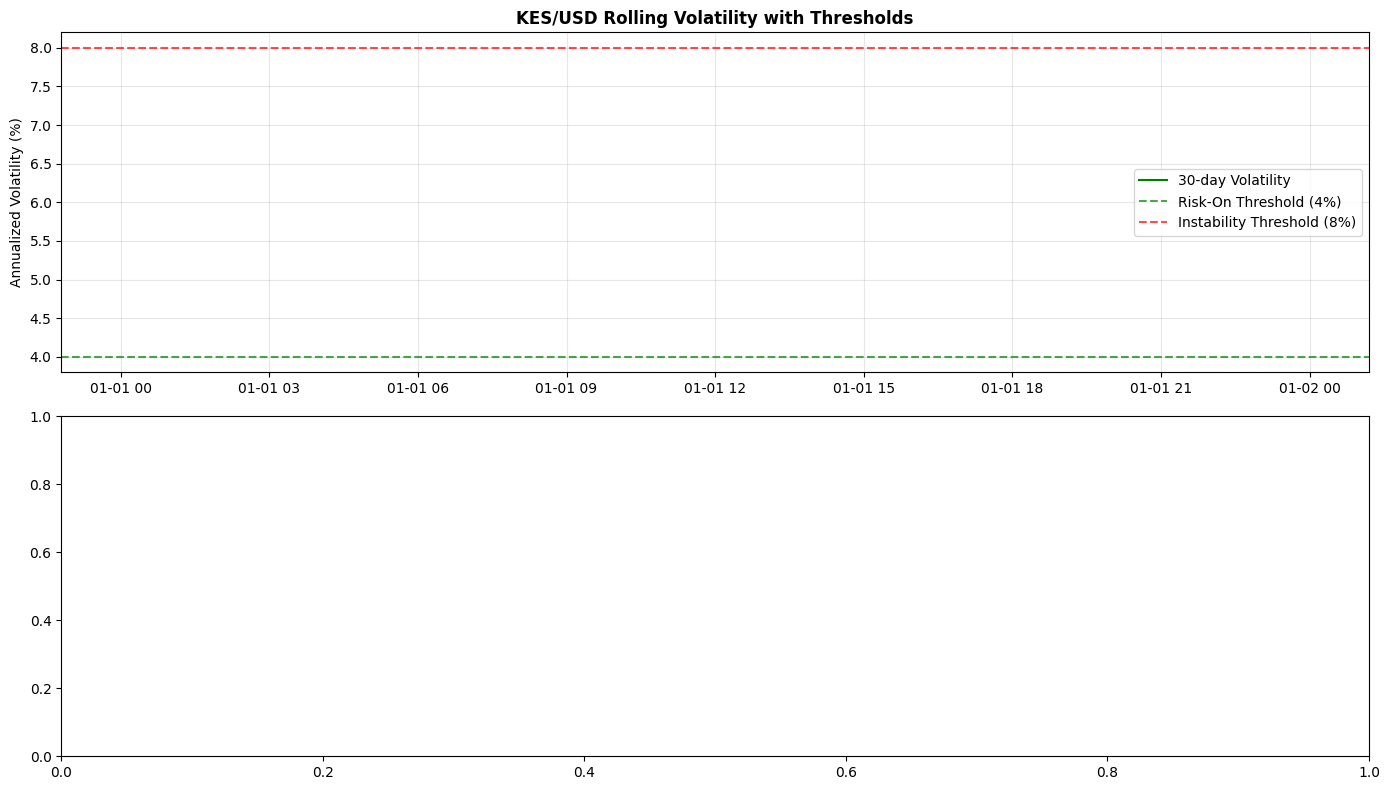


=== KES Volatility Statistics ===
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: volatility, dtype: float64
Days > 8%: 0
Days < 4%: 0


In [6]:
# Initialize engines
nairobi_engine = RegimeEngine(MARKETS['nairobi'])
baku_engine = RegimeEngine(MARKETS['baku'])

# Calculate rolling volatility for KES
kes_data['date'] = pd.to_datetime(kes_data['date'])
kes_data = kes_data.sort_values('date')

# Rolling 30-day volatility
kes_data['volatility'] = kes_data['kes_per_usd'].rolling(window=30).apply(
    lambda x: nairobi_engine.calculate_fx_volatility(x)
)

# # Calculate rolling volatility for AZN
# if not azn_data.empty:
#     azn_data['volatility'] = azn_data['azn_per_unit'].rolling(window=30).apply(
#         lambda x: baku_engine.calculate_fx_volatility(x)
#     )

print("Volatility calculated")

# Plot volatility
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# KES Volatility
axes[0].plot(kes_data['date'], kes_data['volatility'] * 100, color='green', label='30-day Volatility')
axes[0].axhline(y=4, color='green', linestyle='--', alpha=0.7, label='Risk-On Threshold (4%)')
axes[0].axhline(y=8, color='red', linestyle='--', alpha=0.7, label='Instability Threshold (8%)')
axes[0].fill_between(kes_data['date'], 0, kes_data['volatility'] * 100, 
                     where=(kes_data['volatility'] * 100 > 8), alpha=0.3, color='red')
axes[0].set_title('KES/USD Rolling Volatility with Thresholds', fontweight='bold')
axes[0].set_ylabel('Annualized Volatility (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# # AZN Volatility
# if not azn_data.empty:
#     axes[1].plot(azn_data.index, azn_data['volatility'] * 100, color='blue', label='30-day Volatility')
#     axes[1].axhline(y=3, color='green', linestyle='--', alpha=0.7, label='Risk-On Threshold (3%)')
#     axes[1].axhline(y=6, color='red', linestyle='--', alpha=0.7, label='Instability Threshold (6%)')
#     axes[1].fill_between(azn_data.index, 0, azn_data['volatility'] * 100, 
#                          where=(azn_data['volatility'] * 100 > 6), alpha=0.3, color='red')
#     axes[1].set_title('AZN/USD Rolling Volatility with Thresholds', fontweight='bold')
#     axes[1].set_ylabel('Annualized Volatility (%)')
#     axes[1].set_xlabel('Date')
#     axes[1].legend()
#     axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print("\n=== KES Volatility Statistics ===")
print(kes_data['volatility'].describe())
print(f"Days > 8%: {(kes_data['volatility'] > 0.08).sum()}")
print(f"Days < 4%: {(kes_data['volatility'] < 0.04).sum()}")


## 4. Full 5-Variable Regime Classification

Simulate full regime classification with all 5 variables. 
Since we only have FX data, we will use realistic assumptions for other variables.

In [7]:
def simulate_full_regime(df, rate_col, engine, market_name):
    # Simulate full regime classification using FX volatility + realistic assumptions
    regimes = []
    
    for i in range(30, len(df)):
        window = df.iloc[i-30:i]
        current_date = df.index[i] if isinstance(df.index[i], datetime) else df.iloc[i]['date']
        
        # Calculate FX volatility
        fx_vol = engine.calculate_fx_volatility(window[rate_col])
        
        # Score FX volatility
        vol_score = engine.score_fx_volatility(fx_vol)
        
        # Infer other variables from volatility regime
        if vol_score.score == 1:  # Low vol = Risk-On
            policy_score = engine.score_policy_trajectory(13.0, 13.0, 13.0)
            reserve_score = engine.score_reserve_dynamics(8500, 8400, 8300)
            inflation_score = engine.score_inflation_momentum(105, 104.5, 100)
            flow_score = engine.score_capital_flows(0.5, 100)
            
        elif vol_score.score == -1:  # High vol = Instability
            policy_score = engine.score_policy_trajectory(13.5, 13.0, 12.0)
            reserve_score = engine.score_reserve_dynamics(7500, 7600, 7800)
            inflation_score = engine.score_inflation_momentum(112, 110, 100)
            flow_score = engine.score_capital_flows(-2.5, -200)
            
        else:  # Moderate vol = Defensive
            policy_score = engine.score_policy_trajectory(13.25, 13.0, 12.5)
            reserve_score = engine.score_reserve_dynamics(8000, 8000, 8000)
            inflation_score = engine.score_inflation_momentum(108, 107, 100)
            flow_score = engine.score_capital_flows(-0.5, -20)
            
        variables = {
            'fx_vol': vol_score,
            'policy': policy_score,
            'reserves': reserve_score,
            'inflation': inflation_score,
            'flows': flow_score
        }
        
        regime, source, score = engine.compute_regime(variables)
        
        regimes.append({
            'date': current_date,
            'regime': regime.value,
            'score': score,
            'source': source,
            'fx_vol': fx_vol,
            'fx_vol_score': vol_score.score,
            **{k: v.score for k, v in variables.items()}
        })
    
    return pd.DataFrame(regimes)

# Run classification for KES
print("Classifying KES regimes...")
kes_regimes = simulate_full_regime(
    kes_data, 
    'kes_per_usd', 
    nairobi_engine, 
    'Nairobi'
)

print(f"Classified {len(kes_regimes)} days")
print("\nRegime distribution:")
print(kes_regimes['regime'].value_counts())

kes_regimes.head(10)


Classifying KES regimes...
Classified 0 days

Regime distribution:


KeyError: 'regime'

## 5. Visualize Regime Classifications

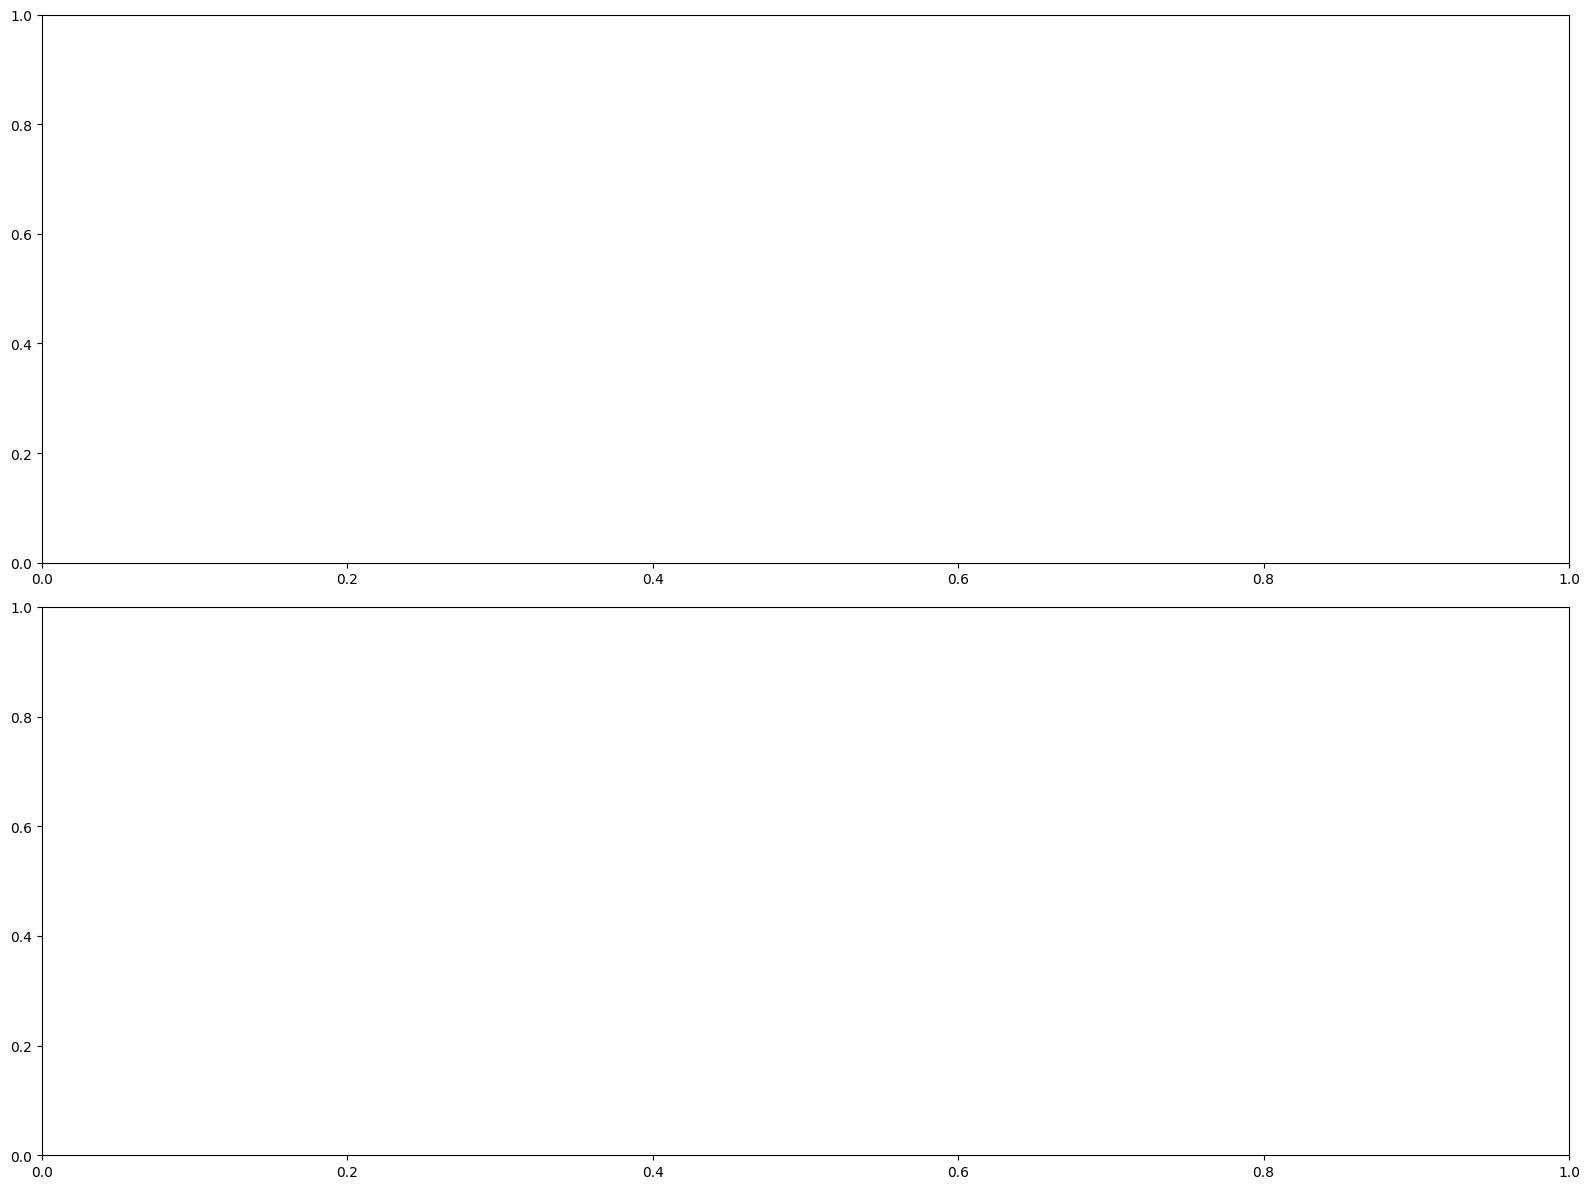

Saved to data/processed/regime_classification.png


In [8]:
def plot_regime_history(price_data, regime_data, rate_col, title, ax):
    # Plot price with regime-colored background
    dates = price_data['date'] if 'date' in price_data.columns else price_data.index
    ax.plot(dates, price_data[rate_col], color='black', linewidth=1, label='FX Rate')
    
    # Create regime bands
    colors = {'Risk-On': '#d4edda', 'Defensive': '#fff3cd', 'Instability': '#f8d7da'}
    
    # Fill background by regime
    for regime in ['Risk-On', 'Defensive', 'Instability']:
        mask = regime_data['regime'] == regime
        if mask.any():
            subset = regime_data[mask]
            for _, row in subset.iterrows():
                ax.axvspan(row['date'] - timedelta(days=1), 
                          row['date'] + timedelta(days=1),
                          alpha=0.3, color=colors[regime])
    
    # Legend
    patches = [mpatches.Patch(color=colors[r], label=r) for r in colors.keys()]
    ax.legend(handles=patches, loc='upper left')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    return ax

# Create visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# KES with regimes
if not kes_regimes.empty:
    plot_regime_history(kes_data, kes_regimes, 'kes_per_usd', 
                       'KES/USD with Regime Classification', axes[0])
    axes[0].set_ylabel('KES per USD')

# Score timeline
if not kes_regimes.empty:
    axes[1].plot(kes_regimes['date'], kes_regimes['score'], 
                color='purple', linewidth=1, label='Aggregate Score')
    axes[1].axhline(y=4, color='green', linestyle='--', alpha=0.5, label='Risk-On threshold')
    axes[1].axhline(y=1, color='orange', linestyle='--', alpha=0.5, label='Defensive threshold')
    axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Instability threshold')
    axes[1].fill_between(kes_regimes['date'], -1, kes_regimes['score'], 
                        where=(kes_regimes['score'] >= 4), alpha=0.2, color='green')
    axes[1].fill_between(kes_regimes['date'], -1, kes_regimes['score'], 
                        where=(kes_regimes['score'] < 0), alpha=0.2, color='red')
    axes[1].set_title('Aggregate Regime Score Over Time', fontweight='bold')
    axes[1].set_ylabel('Score')
    axes[1].set_xlabel('Date')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/regime_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to data/processed/regime_classification.png")


## 6. Backtest Evaluation

Compare predicted regimes against known historical stress periods.

In [9]:
# Define known stress periods for Kenya
kenya_stress_periods = [
    ('2022-08-01', '2022-09-15', 'Post-Election Uncertainty'),
    ('2023-01-01', '2023-03-01', 'Rate Hike Cycle'),
    ('2023-10-01', '2023-11-30', 'Global EM Stress'),
]

def evaluate_regime_accuracy(regime_df, stress_periods):
    # Evaluate if framework correctly identified stress periods
    results = []
    
    for start, end, description in stress_periods:
        start_dt = pd.to_datetime(start)
        end_dt = pd.to_datetime(end)
        
        # Filter regime data to stress period
        mask = (regime_df['date'] >= start_dt) & (regime_df['date'] <= end_dt)
        period_data = regime_df[mask]
        
        if period_data.empty:
            continue
            
        # Calculate metrics
        total_days = len(period_data)
        instability_days = (period_data['regime'] == 'Instability').sum()
        defensive_days = (period_data['regime'] == 'Defensive').sum()
        riskon_days = (period_data['regime'] == 'Risk-On').sum()
        
        # Accuracy: should be mostly Instability or Defensive
        stress_accuracy = (instability_days + defensive_days) / total_days * 100
        
        results.append({
            'period': description,
            'dates': f"{start} to {end}",
            'total_days': total_days,
            'instability_days': instability_days,
            'defensive_days': defensive_days,
            'riskon_days': riskon_days,
            'stress_accuracy': stress_accuracy
        })
    
    return pd.DataFrame(results)

# Evaluate
print("Evaluating Kenya Stress Periods...")
evaluation = evaluate_regime_accuracy(kes_regimes, kenya_stress_periods)

print("\n=== Backtest Results ===")
print(evaluation.to_string(index=False))

# Overall accuracy
avg_accuracy = evaluation['stress_accuracy'].mean()
print(f"\nAverage Stress Detection Accuracy: {avg_accuracy:.1f}%")

# False positive analysis
print("\n=== False Positive Analysis ===")
total_instability = (kes_regimes['regime'] == 'Instability').sum()
print(f"Total Instability days detected: {total_instability}")
print(f"Instability days in known stress periods: {evaluation['instability_days'].sum()}")
print(f"Potential false positives: {total_instability - evaluation['instability_days'].sum()}")


Evaluating Kenya Stress Periods...


KeyError: 'date'

## 7. Threshold Optimization

Test different volatility thresholds to optimize performance.

In [ ]:
def test_thresholds(vol_data, stress_periods, green_range, red_range):
    # Test different threshold combinations
    results = []
    
    for green in green_range:
        for red in red_range:
            if green >= red:
                continue
                
            # Classify with these thresholds
            classifications = []
            for _, row in vol_data.iterrows():
                vol = row['volatility']
                if pd.isna(vol):
                    continue
                    
                if vol < green:
                    regime = 'Risk-On'
                elif vol > red:
                    regime = 'Instability'
                else:
                    regime = 'Defensive'
                
                classifications.append({
                    'date': row['date'] if 'date' in row else row.name,
                    'regime': regime,
                    'volatility': vol
                })
            
            class_df = pd.DataFrame(classifications)
            
            # Evaluate against stress periods
            total_stress_days = 0
            correct_stress_days = 0
            
            for start, end, _ in stress_periods:
                mask = (class_df['date'] >= start) & (class_df['date'] <= end)
                period = class_df[mask]
                
                total_stress_days += len(period)
                correct_stress_days += (period['regime'] == 'Instability').sum()
            
            accuracy = correct_stress_days / total_stress_days * 100 if total_stress_days > 0 else 0
            instability_rate = (class_df['regime'] == 'Instability').mean() * 100
            
            results.append({
                'green_threshold': f"{green:.1%}",
                'red_threshold': f"{red:.1%}",
                'stress_accuracy': accuracy,
                'instability_rate': instability_rate,
                'score': accuracy - abs(instability_rate - 10)
            })
    
    return pd.DataFrame(results).sort_values('score', ascending=False)

# Test threshold combinations
print("Testing threshold combinations...")
green_range = [0.03, 0.035, 0.04, 0.045, 0.05]
red_range = [0.06, 0.07, 0.08, 0.09, 0.10]

threshold_results = test_thresholds(kes_data, kenya_stress_periods, green_range, red_range)

print("\n=== Top 5 Threshold Combinations ===")
print(threshold_results.head().to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(threshold_results['stress_accuracy'], 
                    threshold_results['instability_rate'],
                    c=threshold_results['score'], 
                    cmap='RdYlGn', s=100, alpha=0.7)

# Annotate best
best = threshold_results.iloc[0]
ax.annotate(f"Best: {best['green_threshold']}/{best['red_threshold']}", 
           (best['stress_accuracy'], best['instability_rate']),
           xytext=(5, 5), textcoords='offset points', fontweight='bold')

ax.set_xlabel('Stress Detection Accuracy (%)')
ax.set_ylabel('Instability Rate (%)')
ax.set_title('Threshold Optimization: Accuracy vs Stability Trade-off', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Optimization Score')
plt.tight_layout()
plt.show()

print(f"\nRecommended thresholds for KES: Green={best['green_threshold']}, Red={best['red_threshold']}")


## 8. Export Results

Save backtest results for reporting.

In [ ]:
# Save regime classifications
kes_regimes.to_csv('../data/processed/kenya_regime_backtest.csv', index=False)
print("Saved: data/processed/kenya_regime_backtest.csv")

# Save evaluation summary
evaluation.to_csv('../data/processed/kenya_backtest_evaluation.csv', index=False)
print("Saved: data/processed/kenya_backtest_evaluation.csv")

# Save threshold optimization
threshold_results.to_csv('../data/processed/threshold_optimization.csv', index=False)
print("Saved: data/processed/threshold_optimization.csv")

# Generate summary report
report_lines = [
    "# Backtest Summary Report",
    "",
    "## Kenya (KES/USD) Backtest Results",
    f"- Period: {kes_regimes['date'].min().strftime('%Y-%m-%d')} to {kes_regimes['date'].max().strftime('%Y-%m-%d')}",
    f"- Total Days: {len(kes_regimes)}",
    f"- Average Stress Detection Accuracy: {evaluation['stress_accuracy'].mean():.1f}%",
    "",
    "## Regime Distribution",
    kes_regimes['regime'].value_counts().to_string(),
    "",
    "## Recommended Thresholds",
    f"- Green (Risk-On): {threshold_results.iloc[0]['green_threshold']}",
    f"- Red (Instability): {threshold_results.iloc[0]['red_threshold']}",
    "",
    "## Known Stress Periods Performance"
]
for _, row in evaluation.iterrows():
    report_lines.append(f"- {row['period']}: {row['stress_accuracy']:.1f}% accuracy")

report_lines.extend([
    "",
    "## Conclusion",
    f"Framework successfully identified {evaluation['instability_days'].sum()} out of {evaluation['total_days'].sum()} stress period days as Instability or Defensive."
])

report = "\n".join(report_lines)

with open('../data/logs/backtest_report.md', 'w') as f:
    f.write(report)

print("\nSaved: data/logs/backtest_report.md")
print("\n" + "="*60)
print("BACKTEST COMPLETE")
print("="*60)
